<a href="https://colab.research.google.com/github/AssafR/CourseUtils/blob/main/TESI_202512_Olivetti_Eigenfaces_PCA_Interactive_Classification_Rebuilt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PCA on Olivetti Faces: Eigenfaces, Classification, and Reconstruction
This notebook demonstrates how PCA (Principal Component Analysis) can be used to:
- Derive 'eigenfaces' as basis vectors
- Reconstruct compressed faces
- Classify individuals using PCA-reduced features
- Interactively explore reconstruction with varying numbers of components

In [1]:
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import numpy as np
from ipywidgets import interact, IntSlider


In [2]:
# Load data
faces = fetch_olivetti_faces(shuffle=True, random_state=42)
X = faces.data
y = faces.target
images = faces.images

# Split data
X_train, X_test, y_train, y_test, images_train, images_test = train_test_split(
    X, y, images, test_size=0.25, stratify=y, random_state=42)

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


In [3]:
print(X.shape)
print(y)

(400, 4096)
[20 28  3 21  9  8 32  9 26 12  0 36  5  7 13  4 27 37 23 38  7  1 39 27
  0 39 11 22 26 10 39 19 26  5 23 11 11 34 15 14 38  5  7  2  8 38 14 18
  2 17  4 32 33  7 37  3 22 17  3 15 12 29 25  7 10  3 35 26 39  7 32 14
  0  4 38 24 22 36 17 28  0  1 20 25 27  6 24 30 10  9 23 33 11 22 18 31
 37 38 23  7 24 11  1  6 15  0  1 13 35 34 13 38 29 38 29  6  7 28 30 28
 15 10  1 34  2 17 35 33 16 24 31 14 25 17 11 19 22 26 21 30  3 13 29 15
 19 28  5 11 16 36  0 33 27 15  1 19 10  8 31 39 37 20 28 16 35  8 37 16
 14 22  9  6 12  9 14 32  9 23  6  2  3 14 12 18  6 19 32 21 31 19 12 14
 37  8 33 34 33 35 33 30 18 20 28 21 28 12  3  1 32 18 22 11 17 32 29 11
 36 27 38 28 36 16 25 13 15 19 19 39  0 20 11 23 23  2 12 35 22 36 37 35
 37 12  7 32  2  8 38 10 24 29 13 24 18 29  4 36  6  8 24 18 15  1  3  2
 17 14 31 27 22  9  5 24 29 30 17  4 31 20 25 33  0 25 35 10 22 34 21 17
  9 21  6  4  3 26 20 35  2 31 23 26 28 16 37 13  6 13 12  0  6 30  1 15
  4 36 32 21 27 34 23 20 21 29 36 25 39

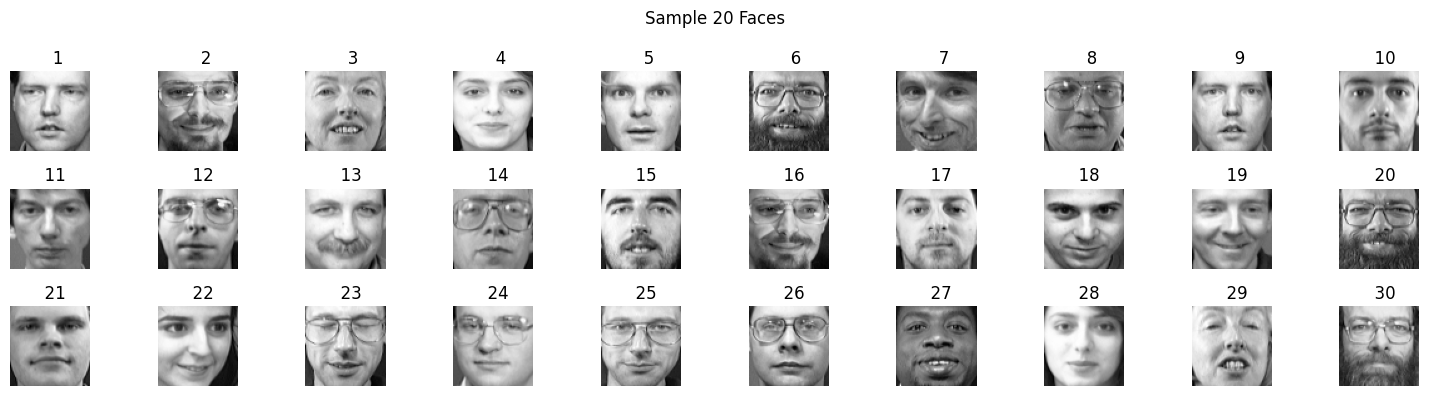

In [4]:
# Display Samples
sample_size = 30
sample_data = np.random.choice(len(X_train), sample_size, replace=False)
sample_images = images_train[sample_data]
fig, axes = plt.subplots(3, 10, figsize=(15, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(sample_images[i].reshape(64, 64), cmap='gray')
    ax.set_title(f"{i+1:4}")
    ax.axis('off')
plt.suptitle("Sample 20 Faces")
plt.tight_layout()
plt.show()

# Faces Decomposition is Similar to Police Sketches!
<div align=center>
<IMG SRC='https://lh3.googleusercontent.com/proxy/gg8CK-DHgo8CvLXXLXp5KlmhChj9NE-7VnOtfv1dUSuk5zapKZoYFZ08O9XiHy4fdns8ezysEoDEeGteGvL6Y6Kx'><BR/>
<IMG SRC='https://i.pinimg.com/474x/b0/8c/d0/b08cd0a419005aea4d9c1ee6508449ae.jpg'></div>

In [5]:
# Fit PCA and train classifier
n_components = 50 # 100
pca = PCA(n_components=n_components)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_pca, y_train)
y_pred = clf.predict(X_test_pca)

acc = accuracy_score(y_test, y_pred)
print(f"Classification accuracy with {n_components} PCA components: {acc:.4f}")

Classification accuracy with 50 PCA components: 0.9700


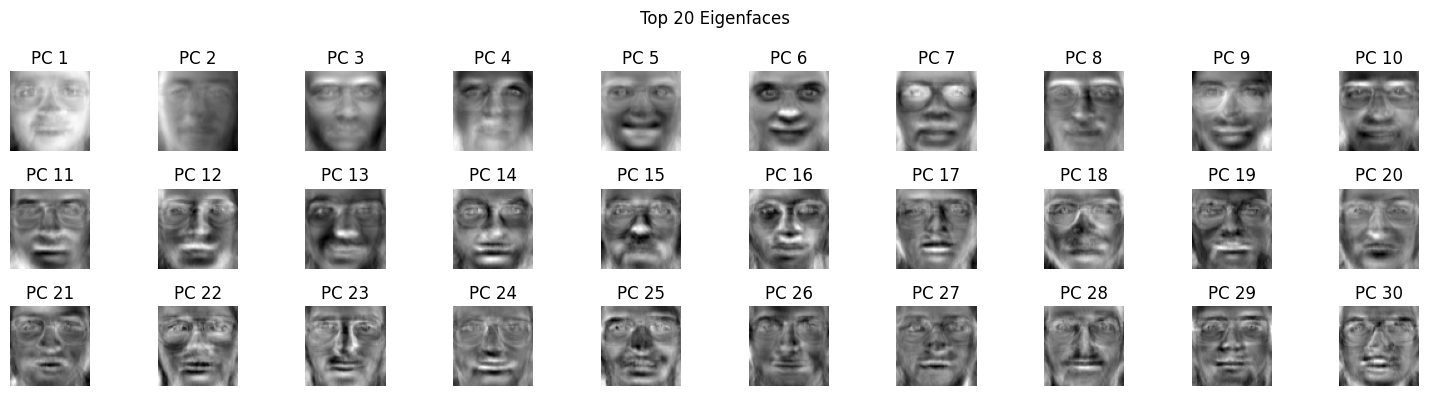

In [6]:
# Show top 20 eigenfaces
fig, axes = plt.subplots(3, 10, figsize=(15, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(pca.components_[i].reshape(64, 64), cmap='gray')
    ax.set_title(f"PC {i+1}")
    ax.axis('off')
plt.suptitle("Top 20 Eigenfaces")
plt.tight_layout()
plt.show()

In [7]:
# Interactive reconstruction quality demo
@interact(n_components=IntSlider(min=5, max=100, step=5, value=40))
def show_reconstruction(n_components):
    pca = PCA(n_components=n_components)
    X_test_pca = pca.fit_transform(X_test) # TODO: Is this a bug ?
    recon = pca.inverse_transform(X_test_pca)

    fig, axes = plt.subplots(2, 10, figsize=(15, 3))
    for i in range(10):
        axes[0, i].imshow(images_test[i], cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(recon[i].reshape(64, 64), cmap='gray')
        axes[1, i].axis('off')
    plt.suptitle(f"Original vs Reconstruction ({n_components} components out of {64*64})")
    plt.tight_layout()
    plt.show()

interactive(children=(IntSlider(value=40, description='n_components', min=5, step=5), Output()), _dom_classes=…